# Sesión 5 — Aprendizaje Federado (tutorial)

**Operaciones de Aprendizaje Automático II · CEIA – FIUBA**

Este notebook es la **parte teórico-práctica guiada** de la Sesión 5. Implementamos **FedAvg desde cero** para *entender* el algoritmo, no solo usarlo: repartimos un dataset entre varios **clientes**, cada uno entrena con **sus** datos, un **servidor** promedia los parámetros (nunca los datos) y comparamos contra el entrenamiento **centralizado**. Después vemos el efecto de los datos **non-IID** y una noción de **privacidad diferencial**.

> **Todo corre de punta a punta** (feedback de ediciones anteriores: los labs deben funcionar). Es pura `numpy` + `scikit-learn` + `matplotlib`, con semilla fija.
>
> **Entorno (uv):** `uv add scikit-learn numpy matplotlib` (y `flwr` solo para la parte opcional de Flower).

In [ ]:
import sys, subprocess
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-learn", "numpy", "matplotlib"])
print("Dependencias listas.")

## 1. La idea en una frase

En lugar de **traer los datos al modelo**, llevamos el **modelo a los datos**. Cada cliente entrena localmente y comparte solo sus **parámetros**; el servidor los combina en un **modelo global**. Así se aprende de todos **sin ver los datos de nadie**.

## 2. Datos y un modelo simple (softmax) desde cero

Usamos el dataset `digits` de scikit-learn (dígitos 0–9, 64 features). El modelo es una **regresión softmax** (regresión logística multiclase) implementada a mano, para poder ver y **promediar sus pesos** — que es exactamente lo que hace FedAvg.

In [1]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

rng = np.random.RandomState(0)
X, y = load_digits(return_X_y=True)
X = StandardScaler().fit_transform(X)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=0, stratify=y)
N_FEAT, N_CLS = X.shape[1], 10
print("train:", Xtr.shape, "· test:", Xte.shape, "· clases:", N_CLS)

train: (1347, 64) · test: (450, 64) · clases: 10


In [2]:
# --- modelo softmax como (W, b); FedAvg promediará estos arrays ---
def init_modelo():
    return np.zeros((N_FEAT, N_CLS)), np.zeros(N_CLS)

def softmax(Z):
    Z = Z - Z.max(axis=1, keepdims=True)
    e = np.exp(Z); return e / e.sum(axis=1, keepdims=True)

def onehot(y):
    O = np.zeros((len(y), N_CLS)); O[np.arange(len(y)), y] = 1; return O

def paso_sgd(W, b, X, y, lr):
    P = softmax(X @ W + b)
    D = (P - onehot(y)) / len(y)
    return W - lr * (X.T @ D), b - lr * D.sum(axis=0)

def accuracy(W, b, X=Xte, y=yte):
    return (np.argmax(X @ W + b, axis=1) == y).mean()

print("Modelo y utilidades listas.")

Modelo y utilidades listas.


## 3. Línea de base: entrenamiento centralizado

Lo habitual: todos los datos juntos en un servidor. Es nuestro **techo de referencia** de accuracy.

In [3]:
def entrenar_centralizado(epocas=200, lr=0.5):
    W, b = init_modelo()
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xtr, ytr, lr)
    return W, b

Wc, bc = entrenar_centralizado()
acc_central = accuracy(Wc, bc)
print(f"Accuracy centralizada: {acc_central:.3f}")

Accuracy centralizada: 0.969


## 4. Repartir el dataset entre clientes (paso 1)

Simulamos **K clientes**. La partición **IID** le da a cada cliente una muestra parecida del total (todas las clases, balanceadas).

In [4]:
def particionar_iid(K):
    idx = rng.permutation(len(Xtr))
    return [(Xtr[c], ytr[c]) for c in np.array_split(idx, K)]

clientes = particionar_iid(5)
print("nº de clientes:", len(clientes))
print("tamaños:", [len(Xc) for Xc, _ in clientes])

nº de clientes: 5
tamaños: [270, 270, 269, 269, 269]


## 5. Entrenamiento local + FedAvg (pasos 2 y 3)

- **Local:** cada cliente parte del **modelo global**, hace unas épocas de SGD con **sus** datos y devuelve sus pesos + su número de datos.
- **Agregación (FedAvg):** el servidor promedia los pesos **ponderando por la cantidad de datos** de cada cliente:  `w_global = Σ_k (n_k / n) · w_k`.

Una **ronda de comunicación** = entrenar en los clientes + agregar. Repetimos R rondas.

Usamos **participación parcial** (una fracción de clientes por ronda), como en un sistema real de móviles.

In [5]:
def entrenar_local(W_glob, b_glob, Xc, yc, epocas=25, lr=0.5):
    W, b = W_glob.copy(), b_glob.copy()          # parte del modelo global
    for _ in range(epocas):
        W, b = paso_sgd(W, b, Xc, yc, lr)
    return W, b, len(Xc)                          # pesos + nº de datos (NO los datos)

def fedavg(actualizaciones):
    n = sum(nk for _, _, nk in actualizaciones)
    W = sum((nk / n) * Wk for Wk, _, nk in actualizaciones)
    b = sum((nk / n) * bk for _, bk, nk in actualizaciones)
    return W, b

def federado(clientes, R=20, frac=0.4, epocas=25, lr=0.5):
    W, b = init_modelo()
    K, m = len(clientes), max(1, int(frac * len(clientes)))
    historia = []
    for _ in range(R):
        sel = rng.choice(K, m, replace=False)     # subconjunto de clientes por ronda
        ups = [entrenar_local(W, b, *clientes[i][:2], epocas, lr) for i in sel]
        W, b = fedavg(ups)                         # el servidor solo promedia pesos
        historia.append(accuracy(W, b))
    return W, b, historia

_, _, hist_iid = federado(clientes)
print(f"Accuracy federada (IID), última ronda: {hist_iid[-1]:.3f}")

Accuracy federada (IID), última ronda: 0.973


## 6. IID vs non-IID (paso 4)

La partición **non-IID** es la realista: cada cliente ve datos **sesgados** (aquí, solo ~2 de las 10 clases). Con participación parcial y varios pasos locales, los modelos locales **divergen** y la agregación se vuelve **inestable** y algo peor.

In [6]:
def particionar_no_iid(K, clases_por_cliente=2):
    order = np.argsort(ytr)                        # ordenar por etiqueta
    shards = np.array_split(order, K * clases_por_cliente)
    rng.shuffle(shards)
    clientes = []
    for k in range(K):
        idx = np.concatenate(shards[k*clases_por_cliente:(k+1)*clases_por_cliente])
        clientes.append((Xtr[idx], ytr[idx]))
    return clientes

clientes_niid = particionar_no_iid(5)
_, _, hist_niid = federado(clientes_niid)
print(f"IID     → {hist_iid[-1]:.3f}")
print(f"non-IID → {hist_niid[-1]:.3f}   (y mucho más inestable, ver el gráfico)")

IID     → 0.973
non-IID → 0.958   (y mucho más inestable, ver el gráfico)


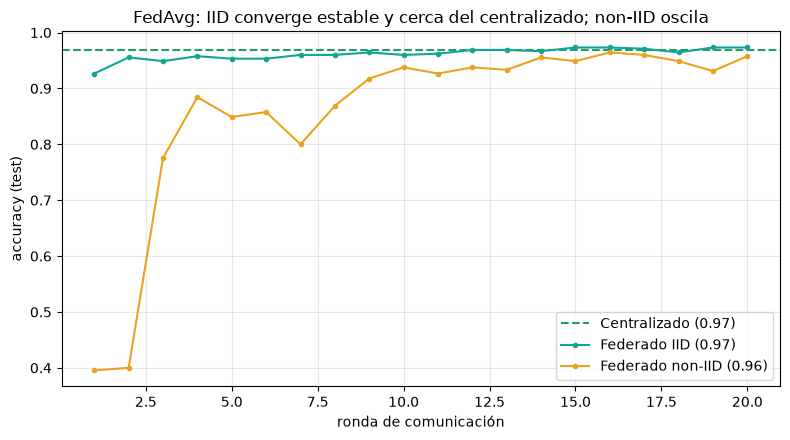

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4.5))
plt.axhline(acc_central, ls="--", color="#1F9D6B", label=f"Centralizado ({acc_central:.2f})")
plt.plot(range(1,len(hist_iid)+1),  hist_iid,  "-o", ms=3, color="#12A594", label=f"Federado IID ({hist_iid[-1]:.2f})")
plt.plot(range(1,len(hist_niid)+1), hist_niid, "-o", ms=3, color="#EAA221", label=f"Federado non-IID ({hist_niid[-1]:.2f})")
plt.xlabel("ronda de comunicación"); plt.ylabel("accuracy (test)")
plt.title("FedAvg: IID converge estable y cerca del centralizado; non-IID oscila")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

**Lo que se ve:** con datos **IID**, el federado sube de forma **estable** y llega **muy cerca** del centralizado, *sin mover un solo dato*. Con datos **non-IID**, la curva **oscila** (cada ronda entrena clientes muy distintos) y termina algo **peor**: ese es el costo de la heterogeneidad. Se mitiga con más rondas, **menos pasos locales**, o algoritmos como FedProx.

## 7. ¿Es privado de verdad? Privacidad diferencial (DP-FedAvg)

Federar ya evita mover los datos, pero los **parámetros** pueden filtrar información sobre un usuario. La **privacidad diferencial (DP)** lo acota de forma medible. En FL se aplica a **nivel de usuario** con los mismos pasos que muestran los slides:

1. Tomar un lote de clientes.
2. **Recortar (clip)** el *update* de cada cliente a una norma L2 máxima `S` → acota cuánto puede influir **un usuario** (la *sensibilidad*).
3. **Promediar** los updates recortados.
4. **Agregar ruido** gaussiano proporcional a `S` (multiplicador de ruido `z`).
5. Incorporar al modelo global. Repetir.

Más ruido = más privacidad y menos accuracy: el **trade-off privacidad vs performance**.

In [8]:
def dp_fedavg(clientes, S=5.0, z=1.0, R=20, epocas=25, lr=0.5):
    """DP-FedAvg a nivel de usuario: recorta el update de cada cliente a norma L2 S,
    promedia, y agrega ruido ~ N(0, (z*S/m)^2). z=0 -> sin ruido."""
    W, b = init_modelo()
    m = len(clientes)
    for _ in range(R):
        dWs, dbs = [], []
        for Xc, yc in clientes:
            Wl, bl, _ = entrenar_local(W, b, Xc, yc, epocas, lr)
            dW, db = Wl - W, bl - b                          # update del cliente
            norm = np.sqrt((dW**2).sum() + (db**2).sum())    # 2) norma del update
            factor = min(1.0, S / (norm + 1e-12))            #    recorte a S
            dWs.append(dW * factor); dbs.append(db * factor)
        aW = np.mean(dWs, axis=0); ab = np.mean(dbs, axis=0) # 3) promedio
        aW = aW + rng.normal(0, z * S / m, aW.shape)         # 4) ruido ~ sensibilidad
        ab = ab + rng.normal(0, z * S / m, ab.shape)
        W, b = W + aW, b + ab                                # 5) incorporar
    return accuracy(W, b)

print(f"Sin ruido (z=0):   {dp_fedavg(clientes, S=5.0, z=0.0):.3f}")
for z in [0.5, 1.0, 2.0, 4.0]:
    print(f"DP  z={z:<4}        {dp_fedavg(clientes, S=5.0, z=z):.3f}")

Sin ruido (z=0):   0.973
DP  z=0.5         0.829
DP  z=1.0         0.731
DP  z=2.0         0.511
DP  z=4.0         0.298


A medida que sube el multiplicador de ruido `z`, la accuracy **baja**: ese es el **trade-off privacidad vs performance** en acción — el mismo eje del Mini-TP.

**Cómo encaja con el resto de la privacidad:**
- Lo de arriba es **DP central** (el servidor recorta/ruidea al agregar): más fácil de mantener buena utilidad, pero hay que confiar en el servidor.
- **DP local:** el ruido se agrega en cada dispositivo → confianza mínima en el servidor, a costa de más utilidad.
- **DP distribuida + agregación segura:** cada cliente recorta y ruidea poco, y los updates se **suman de forma cifrada** (el servidor solo ve la suma) → lo mejor de ambos. Estas dos quedan a nivel conceptual (ver los slides); acá implementamos el patrón central.
- Cuantos **más usuarios**, mejor privacidad (ε menor) por el mismo costo de utilidad.

## 8. Cómo se ve con un framework (Flower) — opcional

Desde cero se entiende, pero en la práctica se usa un framework. Con **Flower** (`flwr`) el mismo FedAvg se organiza en un `Client` (entrena local) y una `Strategy` (agrega en el servidor). Estructura (no se ejecuta aquí; requiere `uv add flwr`):

```python
import flwr as fl

class ClienteFL(fl.client.NumPyClient):
    def get_parameters(self, config):        # pesos actuales
        return [W, b]
    def fit(self, parameters, config):       # entrenamiento local
        W, b = parameters
        W, b, n = entrenar_local(W, b, Xc, yc)
        return [W, b], n, {}
    def evaluate(self, parameters, config):  # evaluación local
        W, b = parameters
        return float(1 - accuracy(W, b)), len(Xc), {"acc": accuracy(W, b)}

# fl.simulation.start_simulation(client_fn=..., num_clients=5,
#     strategy=fl.server.strategy.FedAvg())   # <- misma idea que arriba
```
La lógica es idéntica a la que implementamos: clientes que entrenan y devuelven pesos, un servidor que hace **FedAvg**.

## 9. Errores comunes

- **Compartir datos sin querer:** solo se envían parámetros; nunca muestras ni features crudas.
- **Ignorar el non-IID:** siempre probar con datos sesgados, es lo realista.
- **Demasiados pasos locales:** con non-IID, muchos pasos hacen divergir; baja las épocas.
- **No ponderar por datos:** FedAvg pesa por `n_k`; olvidarlo sesga el modelo global.
- **Creer que federado = privado:** sin DP / agregación segura, los pesos pueden filtrar.
- **Simulación que no corre:** fija versiones y semilla; el notebook debe correr de punta a punta.

---

### Del tutorial al Mini-TP 5

Este pipeline es el molde: en el **Mini-TP 5** federas **tu** modelo (o este dataset), comparas IID / non-IID / centralizado y **analizas el trade-off privacidad vs performance**. Starter en **`mini_tp5_federado_actividad.ipynb`**.